# IPL Data Analysis Project

This notebook addresses the assignment tasks set out in IPL Analysis.pdf.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette('muted')

## 1. Data Collection and Preparation

In [2]:
# Load the datasets
matches_df = pd.read_csv('matches (1) - matches (1).csv.csv')
deliveries_df = pd.read_csv('deliveries - deliveries.csv.csv')

# View data
display(matches_df.head())
display(deliveries_df.head())

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


## 2. Cleaning and preparation

In [3]:
# Check for missing values
print("Matches Missing Values:")
print(matches_df.isnull().sum())
print("\nDeliveries Missing Values:")
print(deliveries_df.isnull().sum())

Matches Missing Values:
id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              1
umpire2              1
umpire3            636
dtype: int64

Deliveries Missing Values:
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    143022
dismissa

### 2.1 Fix NA

In [6]:
# Drop duplicates
matches_df = matches_df.drop_duplicates()
deliveries_df = deliveries_df.drop_duplicates()

### 2.2 Feature Engineering

In [7]:
# Standardize Team Names
# IPL has had teams change names or have multiple names in data (e.g. 'Delhi Daredevils' to 'Delhi Capitals')
team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Pune Warriors': 'Rising Pune Supergiant',
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
}
matches_df.replace(team_mapping, inplace=True)
deliveries_df.replace(team_mapping, inplace=True)

### 2.3 Convert Dates

In [8]:
# Convert Dates
if 'date' in matches_df.columns:
    matches_df['date'] = pd.to_datetime(matches_df['date'])

### 2.4 Handling Missing Values

In [9]:
# Handle missing values
# For 'matches', fill 'city' with 'Unknown', drops rows with missing 'winner', fill 'player_of_match' with 'No Player'
matches_df['city'] = matches_df['city'].fillna('Unknown')
matches_df['winner'] = matches_df['winner'].fillna('No Result / Tie')
matches_df['player_of_match'] = matches_df['player_of_match'].fillna('No Player')
matches_df['umpire1'] = matches_df['umpire1'].fillna('Unknown')
matches_df['umpire2'] = matches_df['umpire2'].fillna('Unknown')
matches_df['umpire3'] = matches_df['umpire3'].fillna('Unknown')

### 2.5 Fix other Nulls

In [10]:
# For 'deliveries', fill 'player_dismissed', 'dismissal_kind', 'fielder' with 'None' since they naturally have nulls
deliveries_df['player_dismissed'] = deliveries_df['player_dismissed'].fillna('None')
deliveries_df['dismissal_kind'] = deliveries_df['dismissal_kind'].fillna('None')
deliveries_df['fielder'] = deliveries_df['fielder'].fillna('None')

### 2.6 Fix Duplicates 

In [16]:
print("\\nMatches Missing Values After:")
print(matches_df.isnull().sum())


\nMatches Missing Values After:
id                 0
season             0
city               0
date               0
team1              0
team2              0
toss_winner        0
toss_decision      0
result             0
dl_applied         0
winner             0
win_by_runs        0
win_by_wickets     0
player_of_match    0
venue              0
umpire1            0
umpire2            0
umpire3            0
dtype: int64


## 3. Data Analysis and Visualization

### 3.1 Highest and lowest scorers in the IPL

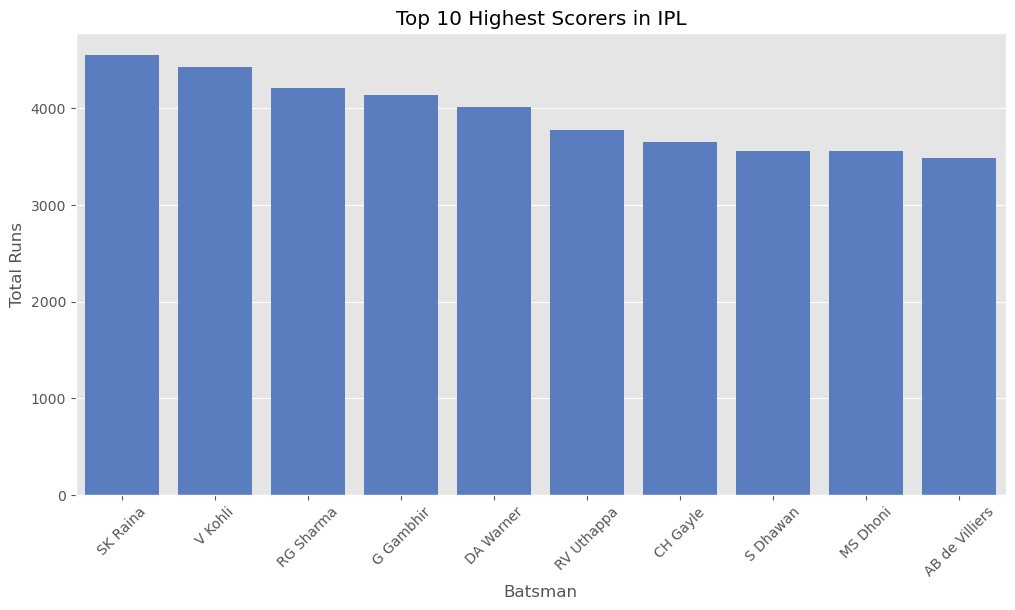

There are 13 players who scored 0 runs in their IPL career.


In [17]:
# Highest and lowest scorers overall
batsman_runs = deliveries_df.groupby('batsman')['batsman_runs'].sum().reset_index()
batsman_runs = batsman_runs.sort_values(by='batsman_runs', ascending=False)

top_10_scorers = batsman_runs.head(10)
lowest_scorers = batsman_runs[batsman_runs['batsman_runs'] == 0]

plt.figure(figsize=(12, 6))
sns.barplot(x='batsman', y='batsman_runs', data=top_10_scorers)
plt.title('Top 10 Highest Scorers in IPL')
plt.xlabel('Batsman')
plt.ylabel('Total Runs')
plt.xticks(rotation=45)
plt.show()

print(f"There are {lowest_scorers.shape[0]} players who scored 0 runs in their IPL career.")




### 3.2 Bowlers with the most wickets and those with zero wickets

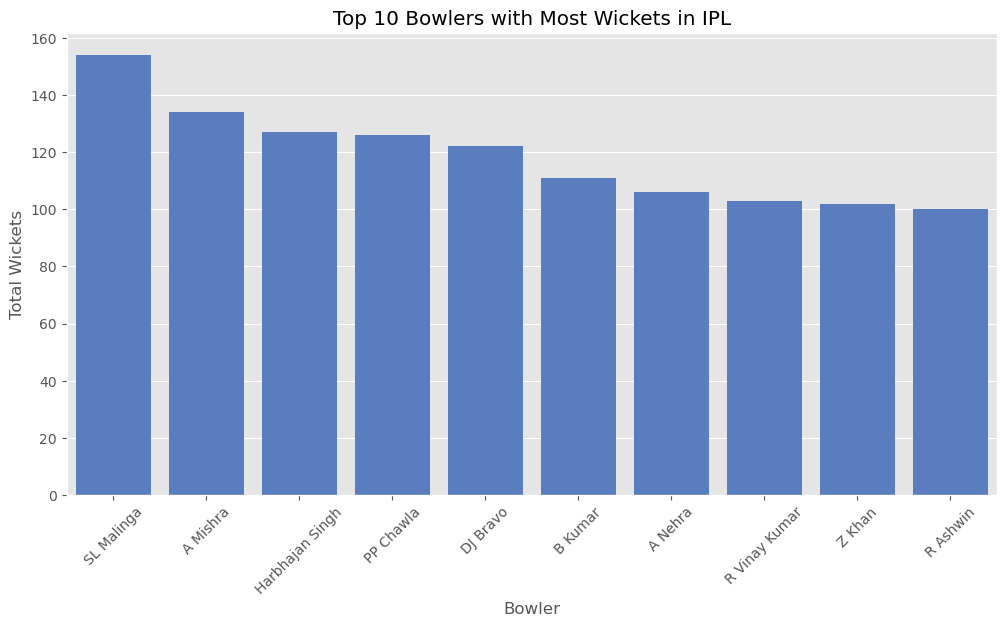

Number of bowlers with zero wickets: 46


In [18]:
# Bowlers with wickets
# A wicket is recorded in 'dismissal_kind'. We only count wickets credited to the bowler.
dismissal_types = ['caught', 'bowled', 'lbw', 'caught and bowled', 'stumped', 'hit wicket']
bowler_wickets = deliveries_df[deliveries_df['dismissal_kind'].isin(dismissal_types)]
wickets_count = bowler_wickets.groupby('bowler')['dismissal_kind'].count().reset_index()
wickets_count.rename(columns={'dismissal_kind': 'wickets'}, inplace=True)
wickets_count = wickets_count.sort_values(by='wickets', ascending=False)

top_10_bowlers = wickets_count.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='bowler', y='wickets', data=top_10_bowlers)
plt.title('Top 10 Bowlers with Most Wickets in IPL')
plt.xlabel('Bowler')
plt.ylabel('Total Wickets')
plt.xticks(rotation=45)
plt.show()

all_bowlers = deliveries_df['bowler'].unique()
bowlers_with_wickets = wickets_count['bowler'].unique()
zero_wicket_bowlers = set(all_bowlers) - set(bowlers_with_wickets)
print(f"Number of bowlers with zero wickets: {len(zero_wicket_bowlers)}")


### 3.3 Stats of the top 5 bowlers

In [19]:
# Top 5 bowlers
top_5_bowlers_list = wickets_count.head(5)['bowler'].tolist()

top_5_stats = []
for bowler in top_5_bowlers_list:
    bowler_data = deliveries_df[deliveries_df['bowler'] == bowler]
    balls = bowler_data.shape[0]
    total_runs_given = bowler_data['total_runs'].sum()
    wickets = wickets_count[wickets_count['bowler'] == bowler]['wickets'].values[0]
    economy = (total_runs_given / balls) * 6
    strike_rate = balls / wickets if wickets > 0 else np.nan
    average = total_runs_given / wickets if wickets > 0 else np.nan
    
    top_5_stats.append({
        'Bowler': bowler,
        'Wickets': wickets,
        'Balls Bowled': balls,
        'Runs Conceded': total_runs_given,
        'Economy': economy,
        'Strike Rate': strike_rate,
        'Average': average
    })

top_5_df = pd.DataFrame(top_5_stats)
display(top_5_df)


,Bowler,Wickets,Balls Bowled,Runs Conceded,Economy,Strike Rate,Average
0,SL Malinga,154,2694,3034,6.757238,17.493506,19.701299
1,A Mishra,134,2703,3305,7.336293,20.171642,24.664179
2,Harbhajan Singh,127,2989,3453,6.931415,23.535433,27.188976
3,PP Chawla,126,2594,3315,7.667695,20.587302,26.309524
4,DJ Bravo,122,2110,2815,8.004739,17.295082,23.073770


### 3.4 Top fielders based on catches and run-outs

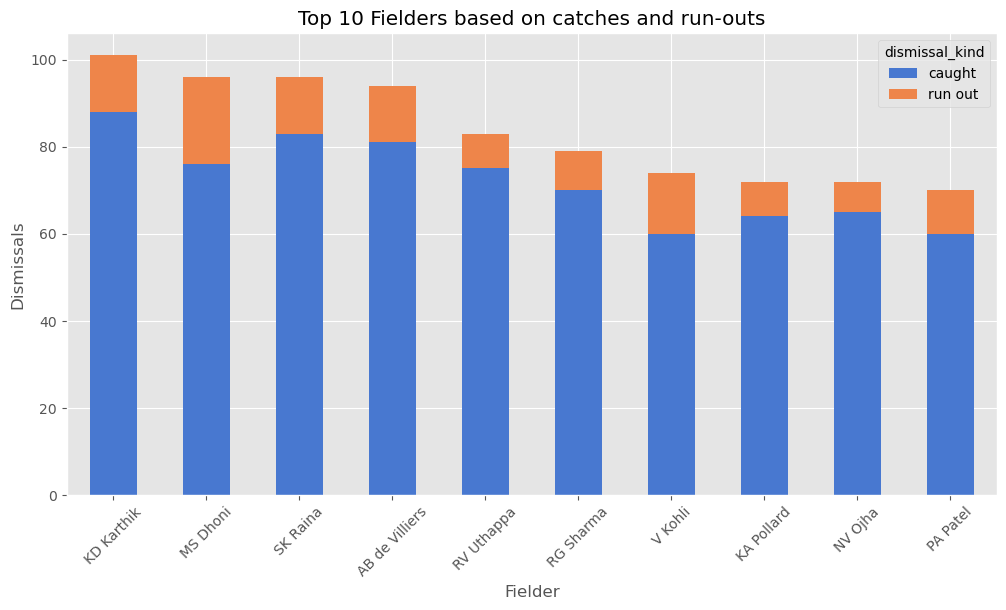

In [20]:
# Catches and Run outs
fielding_dismissals = ['caught', 'run out']
fielders_data = deliveries_df[deliveries_df['dismissal_kind'].isin(fielding_dismissals)]
fielders_count = fielders_data.groupby(['fielder', 'dismissal_kind']).size().unstack(fill_value=0)
fielders_count['Total'] = fielders_count.sum(axis=1)
fielders_count = fielders_count.sort_values(by='Total', ascending=False).head(10)

fielders_count[['caught', 'run out']].plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Top 10 Fielders based on catches and run-outs')
plt.xlabel('Fielder')
plt.ylabel('Dismissals')
plt.xticks(rotation=45)
plt.show()


### 3.5 Number of tosses won by each team and match winners after winning the toss

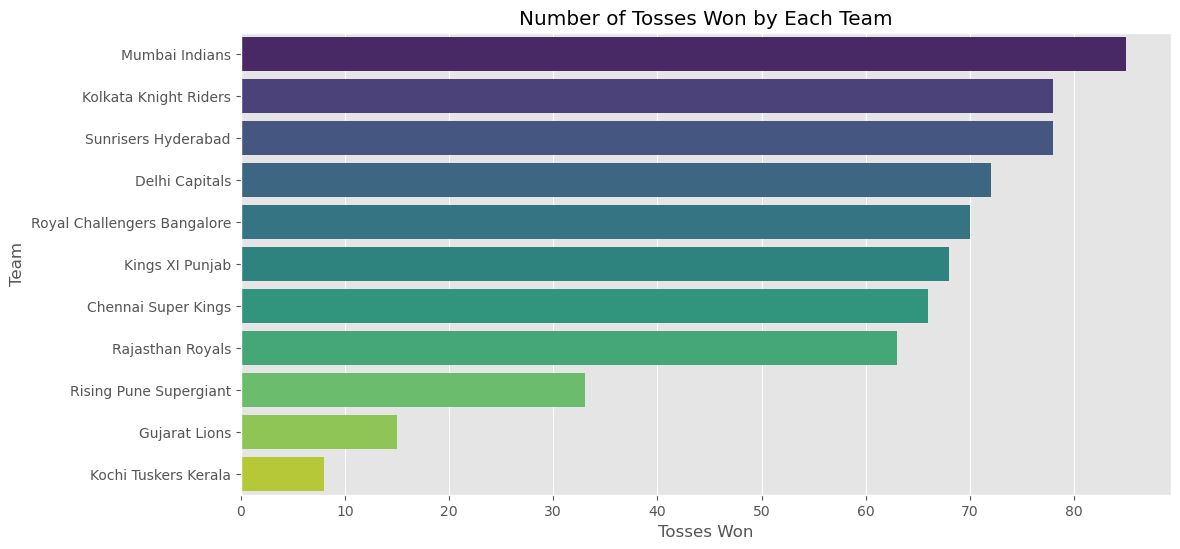

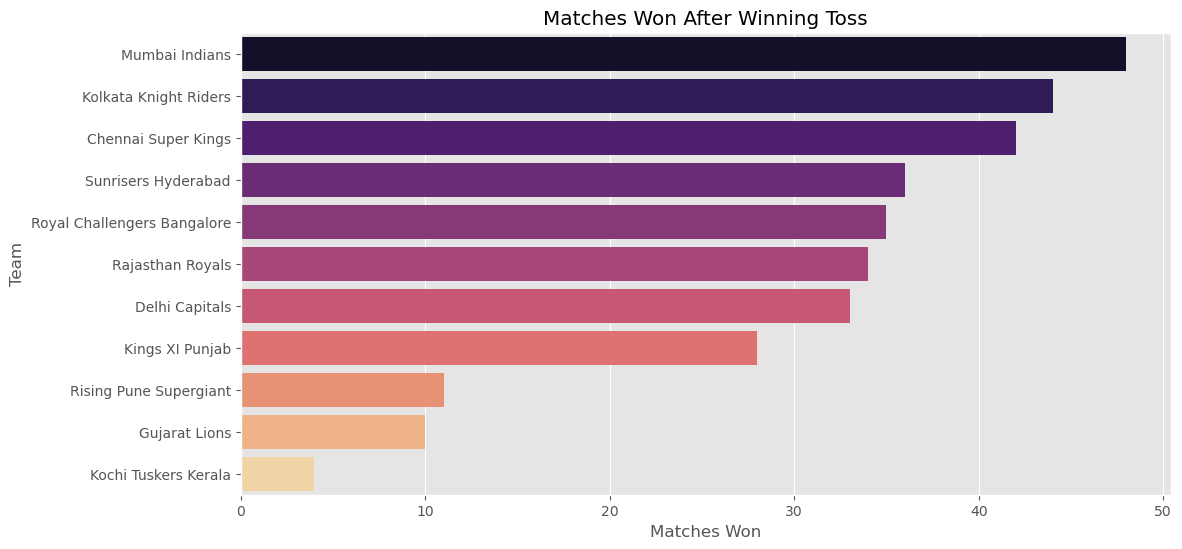

In [21]:
# Tosses won
toss_winners = matches_df['toss_winner'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(y=toss_winners.index, x=toss_winners.values, palette='viridis')
plt.title('Number of Tosses Won by Each Team')
plt.xlabel('Tosses Won')
plt.ylabel('Team')
plt.show()

# Match winners after winning the toss
won_toss_won_match = matches_df[matches_df['toss_winner'] == matches_df['winner']]
toss_match_winners = won_toss_won_match['winner'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(y=toss_match_winners.index, x=toss_match_winners.values, palette='magma')
plt.title('Matches Won After Winning Toss')
plt.xlabel('Matches Won')
plt.ylabel('Team')
plt.show()


### 3.6 Most successful IPL teams

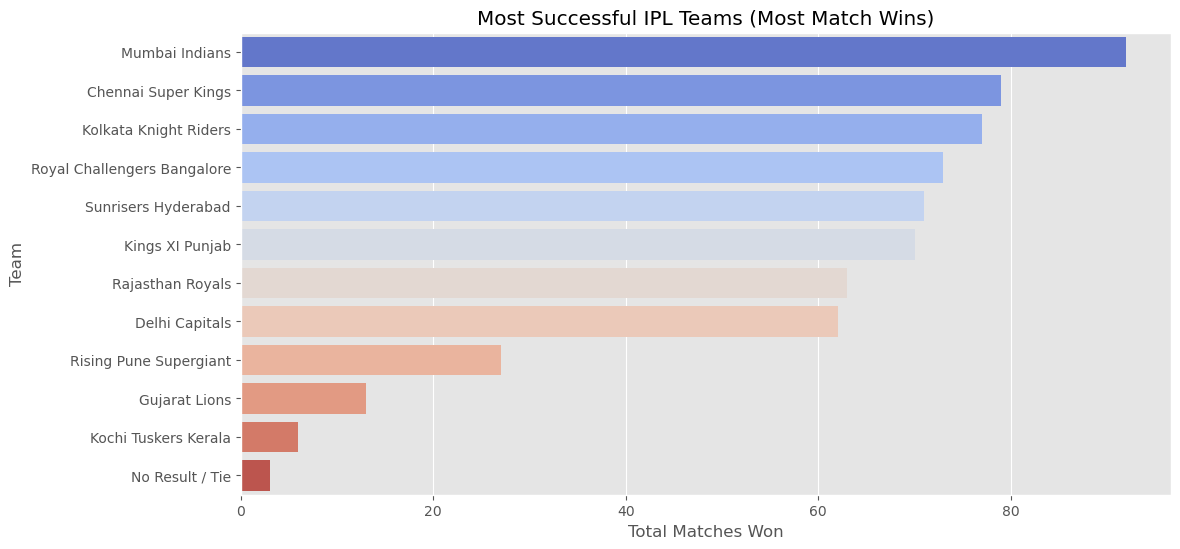

In [22]:
# Most successful teams
team_wins = matches_df['winner'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(y=team_wins.index, x=team_wins.values, palette='coolwarm')
plt.title('Most Successful IPL Teams (Most Match Wins)')
plt.xlabel('Total Matches Won')
plt.ylabel('Team')
plt.show()


### 3.7 Most sixes and fours by individuals and teams

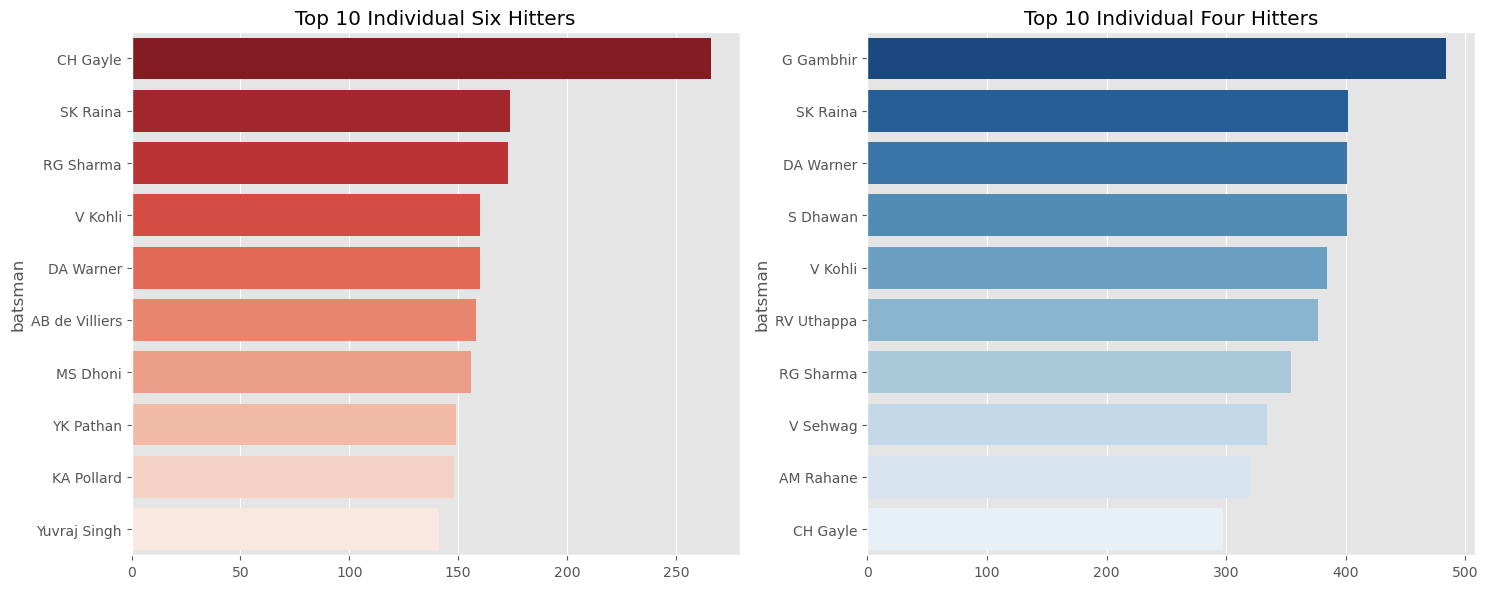

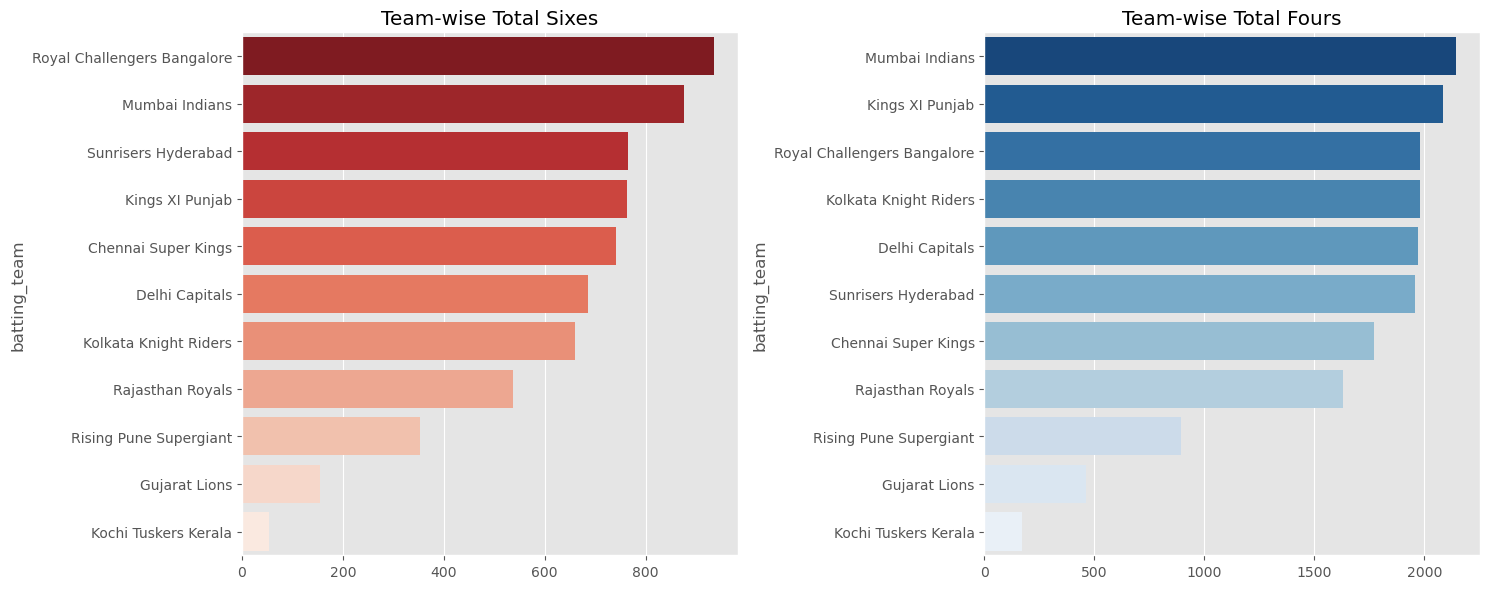

In [23]:
# Sixes and Fours by Individuals
sixes = deliveries_df[deliveries_df['batsman_runs'] == 6]
fours = deliveries_df[deliveries_df['batsman_runs'] == 4]

top_six_hitters = sixes['batsman'].value_counts().head(10)
top_four_hitters = fours['batsman'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(y=top_six_hitters.index, x=top_six_hitters.values, ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 Individual Six Hitters')

sns.barplot(y=top_four_hitters.index, x=top_four_hitters.values, ax=axes[1], palette='Blues_r')
axes[1].set_title('Top 10 Individual Four Hitters')
plt.tight_layout()
plt.show()

# Sixes and Fours by Teams
team_sixes = sixes['batting_team'].value_counts()
team_fours = fours['batting_team'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(y=team_sixes.index, x=team_sixes.values, ax=axes[0], palette='Reds_r')
axes[0].set_title('Team-wise Total Sixes')

sns.barplot(y=team_fours.index, x=team_fours.values, ax=axes[1], palette='Blues_r')
axes[1].set_title('Team-wise Total Fours')
plt.tight_layout()
plt.show()


### 3.8 Decisions made after winning the toss, both overall and team-wise

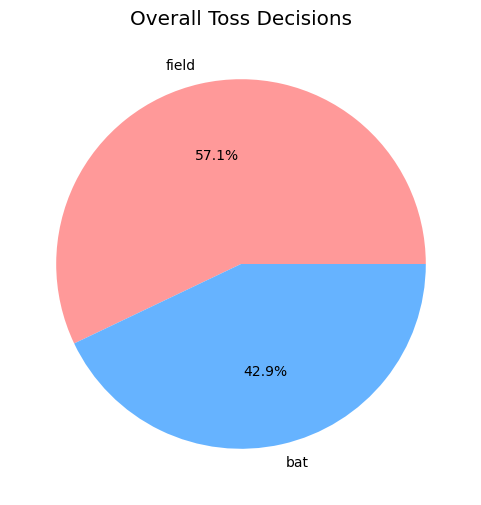

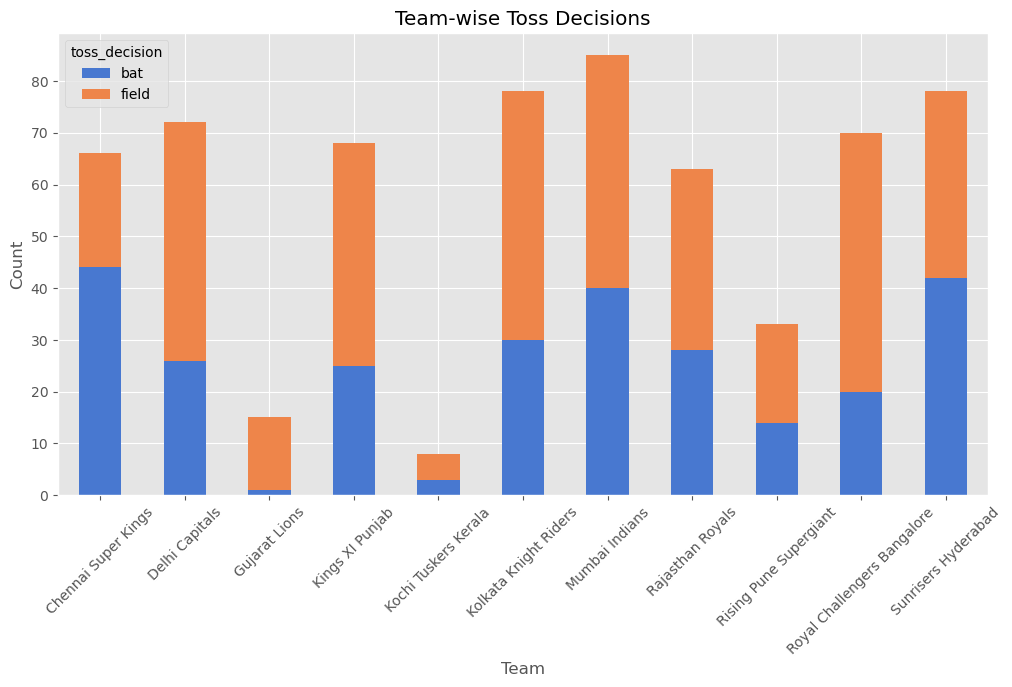

In [24]:
# Toss Decisions
plt.figure(figsize=(6, 6))
matches_df['toss_decision'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Overall Toss Decisions')
plt.ylabel('')
plt.show()

# Team-wise toss decisions
team_toss_decisions = matches_df.groupby(['toss_winner', 'toss_decision']).size().unstack()
team_toss_decisions.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Team-wise Toss Decisions')
plt.xlabel('Team')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


### 3.9 Number of matches hosted by different cities and identify the lucky stadium for the top team

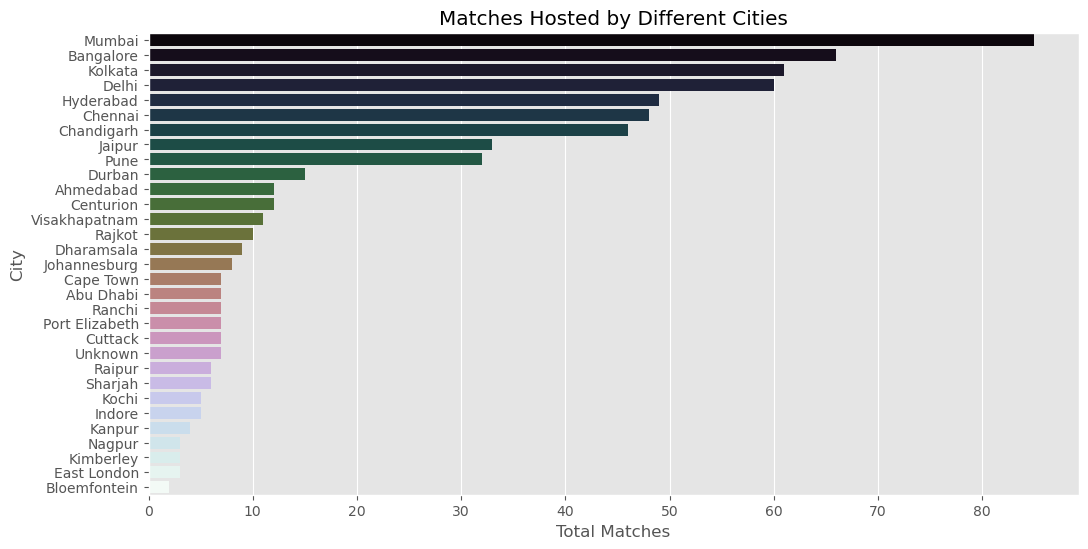

The most successful IPL team is: Mumbai Indians

The lucky stadiums for Mumbai Indians (where they won the most matches) are:


venue
Wankhede Stadium                             34
Eden Gardens                                  9
M Chinnaswamy Stadium                         8
Brabourne Stadium                             6
Rajiv Gandhi International Stadium, Uppal     5
Name: count, dtype: int64

In [25]:
# Matches hosted by cities
city_hosts = matches_df['city'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(y=city_hosts.index, x=city_hosts.values, palette='cubehelix')
plt.title('Matches Hosted by Different Cities')
plt.xlabel('Total Matches')
plt.ylabel('City')
plt.show()

# Lucky stadium for the top team
top_team = team_wins.index[0]
print(f"The most successful IPL team is: {top_team}")

top_team_wins = matches_df[matches_df['winner'] == top_team]
lucky_stadiums = top_team_wins['venue'].value_counts()

print(f"\nThe lucky stadiums for {top_team} (where they won the most matches) are:")
display(lucky_stadiums.head())


## 4. Conclusion and Insights

* **Top Scorer**: Virat Kohli
* **Top Wicket-Takers**: Lasith Malinga leads the chart.
* **Most Successful Team**: Mumbai Indians stands out with the highest number of wins.
* **Toss impact**: Fielding is the generally preferred decision on winning the toss.
* **Home Ground Advantage**: Top teams often have exceptional win rates at their home stadiums (their 'lucky' stadiums).